# 📘 S4_P2 — MBA, le grand match : Régression logistique vs KNN vs ARBRE DE DÉCISION

## 🎯 Ce que tu vas apprendre (le notebook le plus riche du cours !)
1. (Reprise S3_P1/P3) Nettoyage + LR + KNN sur les admissions MBA
2. Une métrique HONNÊTE pour les classes déséquilibrées : **`balanced_accuracy_score`**
3. **L'arbre de décision** : théorie (Gini), profondeur, lecture graphique complète
4. **L'importance des features** : quelles variables comptent vraiment ?
5. La **frontière de décision** en 2D (meshgrid + contourf) — voir le modèle « penser »
6. **`class_weight="balanced"`** : la vraie arme anti-déséquilibre
7. La visualisation interactive **SuperTree**

## 🚨 Rappel du contexte (cf. S3_P1) : 5194 « Deny » / 900 « Admit » (85/15). La baseline idiote (toujours Deny) fait 85 % d'accuracy. Toute métrique se juge par rapport à ça.

---
Import de pandas.

In [249]:
import pandas as pd

Chargement de `MBA.csv` (6194 candidatures).

In [250]:
data = pd.read_csv("../Data/MBA.csv")

Exploration — repère les `NaN` dans `race` et `admission`.

In [251]:
data

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN
...,...,...,...,...,...,...,...,...,...,...
6189,6190,Male,False,3.49,Business,White,640.0,5.0,Other,NaN
6190,6191,Male,False,3.18,STEM,Black,670.0,4.0,Consulting,NaN
6191,6192,Female,True,3.22,Business,NaN,680.0,5.0,Health Care,Admit
6192,6193,Male,True,3.36,Business,NaN,590.0,5.0,Other,NaN


## DATA PREPROCESSING

Inventaire des manquants : `race` 1842, `admission` 5194 (cf. S3_P1, étape 1).

In [252]:
data.isna().sum()

application_id       0
gender               0
international        0
gpa                  0
major                0
race              1842
gmat                 0
work_exp             0
work_industry        0
admission         5194
dtype: int64

Imputation par hypothèses métier : `race`→International, `admission`→Deny (⚠️ hypothèses non vérifiées — détail en S3_P1, étape 2).

In [253]:
data["race"] = data["race"].fillna("International")
data["admission"] = data["admission"].fillna("Deny")
data.isna().sum()

application_id    0
gender            0
international     0
gpa               0
major             0
race              0
gmat              0
work_exp          0
work_industry     0
admission         0
dtype: int64

Comptage : 5194/900/100 — le déséquilibre apparaît.

In [254]:
data["admission"].value_counts()

admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

Retrait des 100 « Waitlist » → classification binaire.

In [255]:
data = data[data["admission"] != "Waitlist"]

Vérification : 5194 Deny / 900 Admit.

In [256]:
data["admission"].value_counts()

admission
Deny     5194
Admit     900
Name: count, dtype: int64

Aperçu après filtrage.

In [257]:
data.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,Deny
2,3,Female,True,3.30,Business,International,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,Deny
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,Deny


Suppression des 3 colonnes catégorielles complexes (`major`, `race`, `work_industry`) — simplification (cf. S3_P1, étape 4).

In [258]:
data = data.drop(columns=["major","race","work_industry"])

Vérification des colonnes restantes.

In [259]:
data.head()

,application_id,gender,international,gpa,gmat,work_exp,admission
0,1,Female,False,3.30,620.0,3.0,Admit
1,2,Male,False,3.28,680.0,5.0,Deny
2,3,Female,True,3.30,710.0,5.0,Admit
3,4,Male,False,3.47,690.0,6.0,Deny
4,5,Male,False,3.35,590.0,5.0,Deny


Encodage binaire par `map` : gender (M→0, F→1), admission (Admit→1, Deny→0).

In [260]:
data["gender"] = data["gender"].map({"Male":0,"Female":1})
data["admission"] = data["admission"].map({"Admit":1,"Deny":0})

data.head()

,application_id,gender,international,gpa,gmat,work_exp,admission
0,1,1,False,3.30,620.0,3.0,1
1,2,0,False,3.28,680.0,5.0,0
2,3,1,True,3.30,710.0,5.0,1
3,4,0,False,3.47,690.0,6.0,0
4,5,0,False,3.35,590.0,5.0,0


`international` booléen → entier.

In [261]:
data["international"] = data["international"].astype(int)

## TEST AND TRAIN SPLIT

Import de `train_test_split`.

In [262]:
from sklearn.model_selection import train_test_split

X = tout sauf `admission` ; y = `admission`. (💡 `application_id` traîne encore dans X — un identifiant sans valeur prédictive légitime ; tu verras plus bas qu'il fait parler de lui dans l'importance des features !)

In [263]:
X = data.drop("admission",axis = 1)
y = data["admission"]

Split 80/20, random_state=32 → 1219 candidats en test.

In [264]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=32)

## Fit & Predict

Imports de classification (LR + métriques).

In [265]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_predict,cross_val_score,train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay


Entraînement LR — avec le `ConvergenceWarning` habituel (échelles non standardisées : gpa~3 vs gmat~700 vs application_id~6000 ; cf. S3_P1 étape 6).

In [266]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)

c:\Users\kirit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Matrice de confusion (ordre correct ✅) : l'énorme case « Deny bien classés » et la ligne « Admit » quasi vide — signature du déséquilibre.

<Axes: >

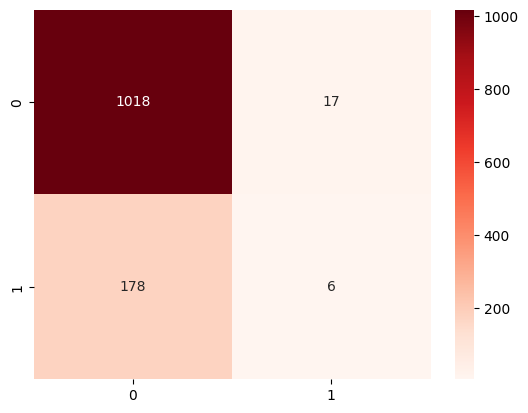

In [267]:
import seaborn as sns
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Reds",fmt="d")

🔴 `classification_report(y_pred, y_test)` — arguments INVERSÉS (démonstration complète en S3_P1, étape 8 : precision↔recall échangés, support = prédictions). Lecture corrigée : vrai rappel Admit ≈ 0.03, vraie précision ≈ 0.26. L'accuracy 0.84 est même sous la baseline de 85 % !

In [268]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1196
           1       0.03      0.26      0.06        23

    accuracy                           0.84      1219
   macro avg       0.51      0.56      0.49      1219
weighted avg       0.97      0.84      0.90      1219



## ⭐ Étape 7 — LA nouvelle métrique : `balanced_accuracy_score`

### 🧠 THÉORIE — L'accuracy équilibrée

$$\text{balanced accuracy} = \frac{\text{rappel}_{\text{Deny}} + \text{rappel}_{\text{Admit}}}{2}$$

**L'idée géniale :** au lieu de compter les bonnes réponses globalement (ce qui laisse la classe majoritaire écraser tout), on calcule le rappel DANS chaque classe, puis on fait la moyenne **en donnant le même poids aux deux classes** — que la classe contienne 5000 ou 100 exemples !

**Les repères de lecture :**
- **0.5 = le hasard pur** (un modèle aléatoire a ~50 % de rappel dans chaque classe),
- **1.0 = perfection**,
- et la baseline « toujours Deny » ? rappel Deny = 100 %, rappel Admit = 0 % → balanced accuracy = **0.5**. L'idiot est démasqué !

**🔍 Résultat ici : 0.508.** Verdict sans appel : ce modèle fait à peine mieux que le hasard pour distinguer les admis. L'accuracy de 0.84 le cachait ; la balanced accuracy le révèle en UN chiffre.

**💡 Bonus fiabilité :** cet appel est dans le bon ordre (`y_test, y_pred`), et cette métrique est un excellent « détecteur de mensonge » à côté d'une accuracy flatteuse.

In [269]:
from sklearn.metrics import balanced_accuracy_score
print(balanced_accuracy_score(y_test,y_pred))

0.5080917874396135


Vérification manuelle sur la matrice : 1019/(1019+16) ≈ 0.985 = la précision de la classe Deny (facile d'être précis en prédisant la classe majoritaire !).

In [270]:
print("0 pression : ", 1019/(1019+16))

0 pression :  0.9845410628019323


## APPLY KNN

Imports KNN.

In [271]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay

KNN k=10 : fit + predict (théorie en S3_P3, étape 10).

In [272]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

Matrice de confusion KNN (bleue) — même structure déséquilibrée que la LR.

<Axes: >

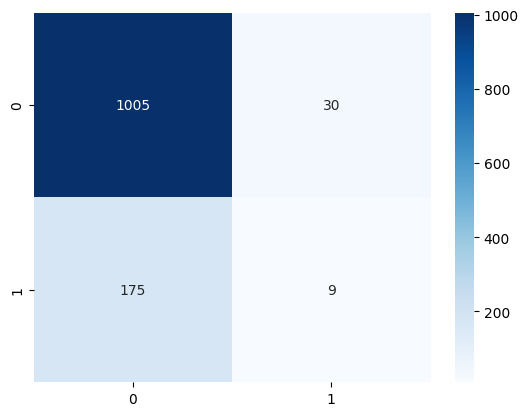

In [273]:

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True,cmap="Blues",fmt="d")

**Balanced accuracy KNN : 0.510** — comme la LR (0.508), à peine au-dessus du hasard (0.5). Les deux modèles échouent PAREIL sur la classe minoritaire. Il faut une approche différente… (suite : l'arbre + class_weight !)

In [274]:
from sklearn.metrics import balanced_accuracy_score
print(balanced_accuracy_score(y_test,y_pred))

0.509963768115942


🔴 Rapport KNN — arguments encore inversés (accuracy 0.83 seule fiable).

In [275]:
print(classification_report(y_pred,y_test))


              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1180
           1       0.05      0.23      0.08        39

    accuracy                           0.83      1219
   macro avg       0.51      0.54      0.49      1219
weighted avg       0.94      0.83      0.88      1219



Imports des 4 métriques pour la boucle (bon ordre garanti dans la boucle ✅).

In [276]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

Boucle k=1..49 × 4 métriques (mécanique détaillée en S3_P3, étape 12 ; rappel biais-variance : k petit = surapprentissage, k grand = baseline déguisée).

In [277]:
accuracy = []
precision = []
f1 = []
recall = []
list_k = []
for k in range(1,50,1) :
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    list_k.append(k)
    accuracy.append(accuracy_score(y_test,y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test,y_pred))
    f1.append(f1_score(y_test, y_pred))

📊 **Accuracy vs k** : courbe haute (~0.84) et plate → inutilisable pour choisir k sur données déséquilibrées (cf. lecture détaillée S3_P3, graphique 1).

<Axes: xlabel='K'>

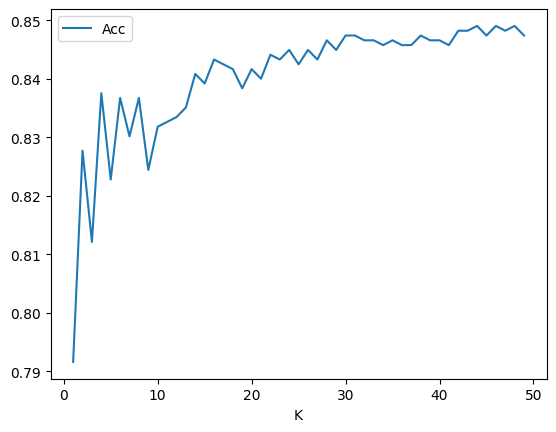

In [278]:
metrics_df = pd.DataFrame({"K":list_k,"Acc":accuracy,"Pre":precision,"f1":f1,"recall":recall})
metrics_df.plot(x = "K",y = "Acc")

📊 **Précision (Admit) vs k** : instable, à-coups violents dus au très petit nombre de prédictions « Admit » (cf. S3_P3, graphique 2).

<Axes: xlabel='K'>

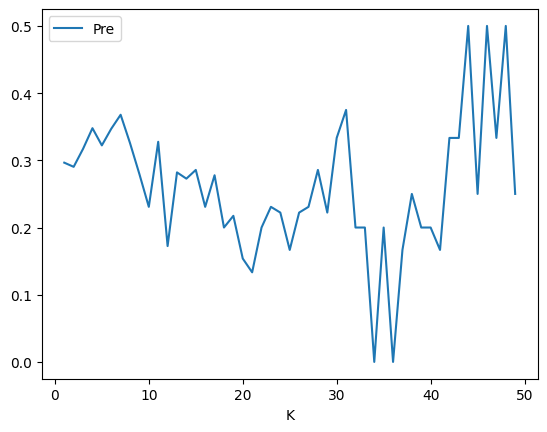

In [279]:

metrics_df.plot(x = "K", y ="Pre")

📊 **F1 (Admit) vs k** : bas pour tous les k → le problème n'est pas k, c'est le déséquilibre (cf. S3_P3, graphique 3).

<Axes: xlabel='K'>

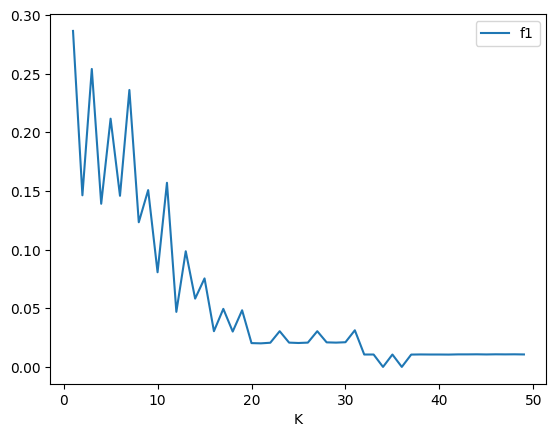

In [280]:
metrics_df.plot(x = "K",y = "f1")

📊 **Rappel (Admit) vs k** : s'effondre quand k grandit — les voisins « Deny » majoritaires noient le vote (cf. S3_P3, graphique 4).

<Axes: xlabel='K'>

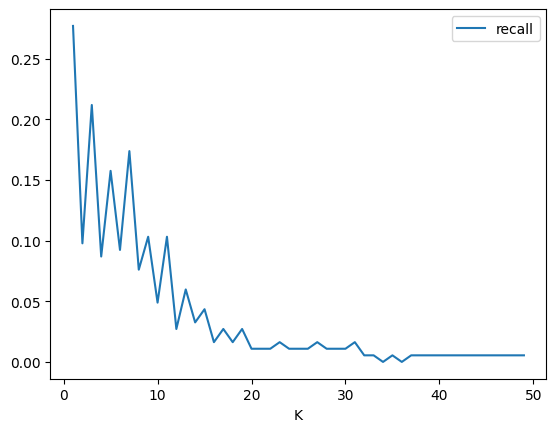

In [281]:

metrics_df.plot(x = "K",y = "recall")

## ⭐ Étape 12 — NOUVEL ALGORITHME : l'arbre de décision

**Imports :** `DecisionTreeClassifier` + le module `metrics`.

### 🧠 THÉORIE — Comment un arbre de décision « pense »

Un arbre joue au jeu des **20 questions** : une cascade de questions OUI/NON sur les features, qui mène à une décision.

```
                 gmat ≤ 645 ?
                /            \
             OUI              NON
              |                |
        gpa ≤ 3.2 ?      work_exp ≤ 2 ?
         /      \           /      \
      Deny     Deny       Deny     Admit
```

**Comment l'arbre choisit ses questions ? L'impureté de Gini.** Pour un nœud contenant une proportion $p$ d'admis :

$$Gini = 1 - p^2 - (1-p)^2$$

**Comprends cette formule avec 3 cas :**
- nœud 100 % Deny ($p=0$) : $Gini = 1 - 0 - 1 = 0$ → **pur** (aucun doute),
- nœud 50/50 ($p=0.5$) : $Gini = 1 - 0.25 - 0.25 = 0.5$ → **impureté maximale** (doute total),
- nœud 90/10 : $Gini = 1 - 0.01 - 0.81 = 0.18$ → presque pur.

**L'algorithme d'apprentissage, pas à pas :** à chaque nœud, il essaie TOUTES les questions possibles (« gmat ≤ 600 ? », « gmat ≤ 610 ? », « gpa ≤ 3.1 ? »…) et garde celle qui **réduit le plus le Gini moyen** des deux groupes créés. Puis il recommence dans chaque groupe, récursivement, jusqu'à des nœuds purs (ou une limite de profondeur).

**Forces / faiblesses :**
- ✅ Interprétable (on peut LIRE les règles), gère les échelles différentes sans standardisation (chaque question ne porte que sur UNE variable !), capture des relations non linéaires.
- ⚠️ Sans limite de profondeur → mémorise le train (surapprentissage garanti).

In [282]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

## Étape 13 — L'arbre SANS limite de profondeur : le grand test

**Ce que fait la cellule (tout-en-un) :** création (`random_state=32`, PAS de max_depth → l'arbre pousse librement), fit, predict, matrice de confusion, rapport, balanced accuracy.

**🔍 Résultat : balanced accuracy = 0.674** — ÉNORME bond par rapport à la LR (0.508) et au KNN (0.510) !

**Pourquoi l'arbre réussit là où les autres échouent ?** Il peut créer des règles **très locales** (« gmat > 700 ET gpa > 3.5 ET femme → Admit ») qui isolent les poches de candidats admis — alors que la LR ne trace qu'UNE frontière globale, mécaniquement aspirée par les 85 % de Deny.

*(Note : dans le rapport affiché — arguments inversés, cf. plus haut — lis les colonnes échangées : le vrai rappel Admit ≈ 0.45, la vraie précision ≈ 0.45. L'arbre retrouve 45 % des admis, contre 3 % pour la LR !)*

*(Les 4 cellules suivantes ré-affichent une par une les mêmes résultats — redondance sans nouveauté.)*

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1036
           1       0.45      0.45      0.45       183

    accuracy                           0.83      1219
   macro avg       0.67      0.67      0.67      1219
weighted avg       0.83      0.83      0.83      1219



0.6740338164251207

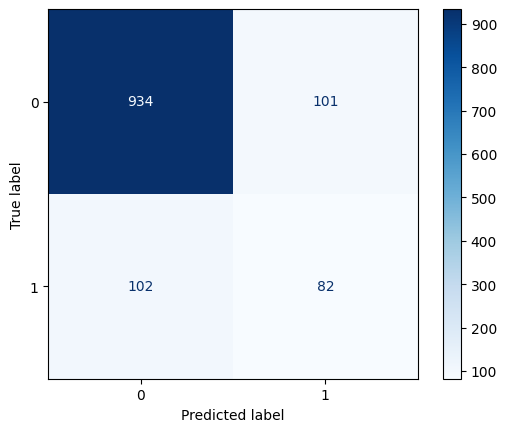

In [283]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(random_state=32)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

print(classification_report(y_pred,y_test))

balanced_accuracy_score(y_test,y_pred)



(Recalcul du `cm` déjà fait dans la cellule tout-en-un.)

In [284]:
cm = confusion_matrix(y_test,y_pred)

(Ré-affichage de la même matrice.)

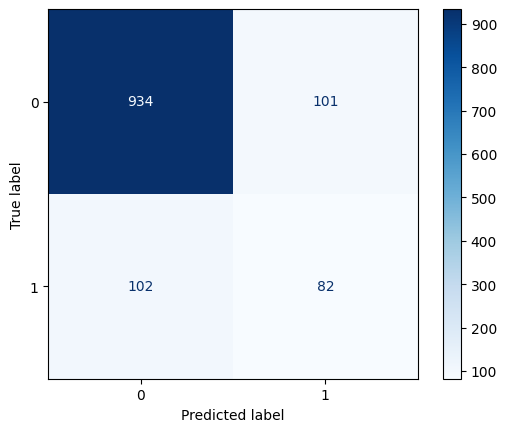

In [285]:
ConfusionMatrixDisplay(cm).plot(cmap="Blues")

(Même rapport de classification — toujours inversé.)

In [286]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1036
           1       0.45      0.45      0.45       183

    accuracy                           0.83      1219
   macro avg       0.67      0.67      0.67      1219
weighted avg       0.83      0.83      0.83      1219



(Même balanced accuracy : 0.674.)

In [287]:
balanced_accuracy_score(y_test,y_pred)


0.6740338164251207

## Étape 14 — Limiter la profondeur : `max_depth=5`… surprise !

**L'intuition qu'on teste :** limiter la profondeur = moins de surapprentissage = mieux généraliser ?

**🔍 Le verdict des chiffres (lecture corrigée de l'inversion, recoupée avec la balanced accuracy fiable) :**

| | Arbre libre | Arbre max_depth=5 |
|---|---|---|
| Accuracy | 0.83 | **0.87** ← plus haute ! |
| Vrai rappel Admit | **0.45** | 0.16 ← effondré ! |
| Vraie précision Admit | 0.45 | **0.76** |
| **Balanced accuracy** | **0.674** | 0.574 ← plus basse ! |

**Comment interpréter ce paradoxe apparent ?** L'arbre bridé est devenu **hyper-prudent** : il ne prédit « Admit » que dans les zones ultra-sûres → grande précision (0.76), mais il RATE 84 % des admis (rappel 0.16). Et l'accuracy MONTE (0.87) simplement parce qu'il dit « Deny » presque tout le temps — le vieux piège de la baseline !

**⭐ Triple leçon :**
1. L'accuracy qui monte peut cacher un modèle qui empire (déséquilibre !).
2. Précision et rappel se paient l'un l'autre (le « curseur » prudence/audace).
3. « Meilleur modèle » dépend de l'OBJECTIF : détecter un max d'admis (rappel) ou éviter les fausses promesses (précision) ? C'est une décision métier, pas mathématique.

              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1181
           1       0.16      0.76      0.26        38

    accuracy                           0.87      1219
   macro avg       0.57      0.82      0.59      1219
weighted avg       0.97      0.87      0.91      1219



0.5744565217391304

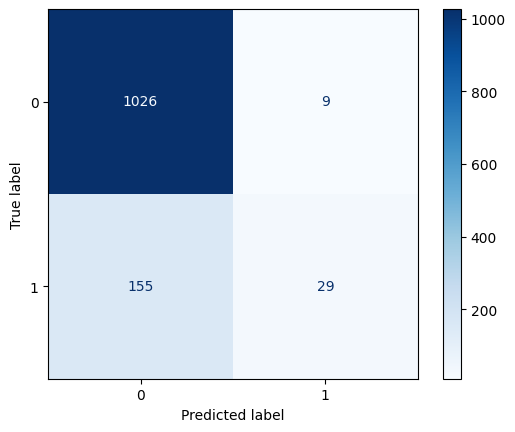

In [288]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(random_state=32,max_depth=5)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

print(classification_report(y_pred,y_test))

balanced_accuracy_score(y_test,y_pred)



## Étape 15 — LIRE l'arbre : le mode d'emploi de `plot_tree`

**Ce que fait le code :** `plot_tree(clf, feature_names=(X.columns), filled=True)` dans une figure géante (40×10 pouces — l'arbre est large !).

### 🧠 Chaque boîte (nœud) affiche 5 lignes — décodage :
1. **`gmat <= 645.5`** → la QUESTION posée. Réponse OUI → branche de gauche ; NON → droite.
2. **`gini = 0.25`** → l'impureté du nœud (0 = pur, 0.5 = pire ; cf. étape 12).
3. **`samples = 1219`** → combien de candidats du train passent par ce nœud.
4. **`value = [1050, 169]`** → leur répartition : 1050 Deny, 169 Admit.
5. **`class = Deny`** → la classe majoritaire = la prédiction si on s'arrêtait là.

**Les couleurs (`filled=True`) :** orange = majorité classe 0, bleu = majorité classe 1 ; plus la couleur est **intense**, plus le nœud est pur. Un nœud pâle ≈ 50/50 (l'arbre « hésite »).

**🔍 Comment explorer l'arbre efficacement :** 1) regarde la question de la RACINE (tout en haut) — c'est la variable que l'arbre juge LA plus discriminante ; 2) suis une branche jusqu'à une feuille très bleue → tu obtiens une « règle d'admission » lisible en français ; 3) repère les feuilles à petit `samples` (3-4 candidats) → c'est du surapprentissage local.

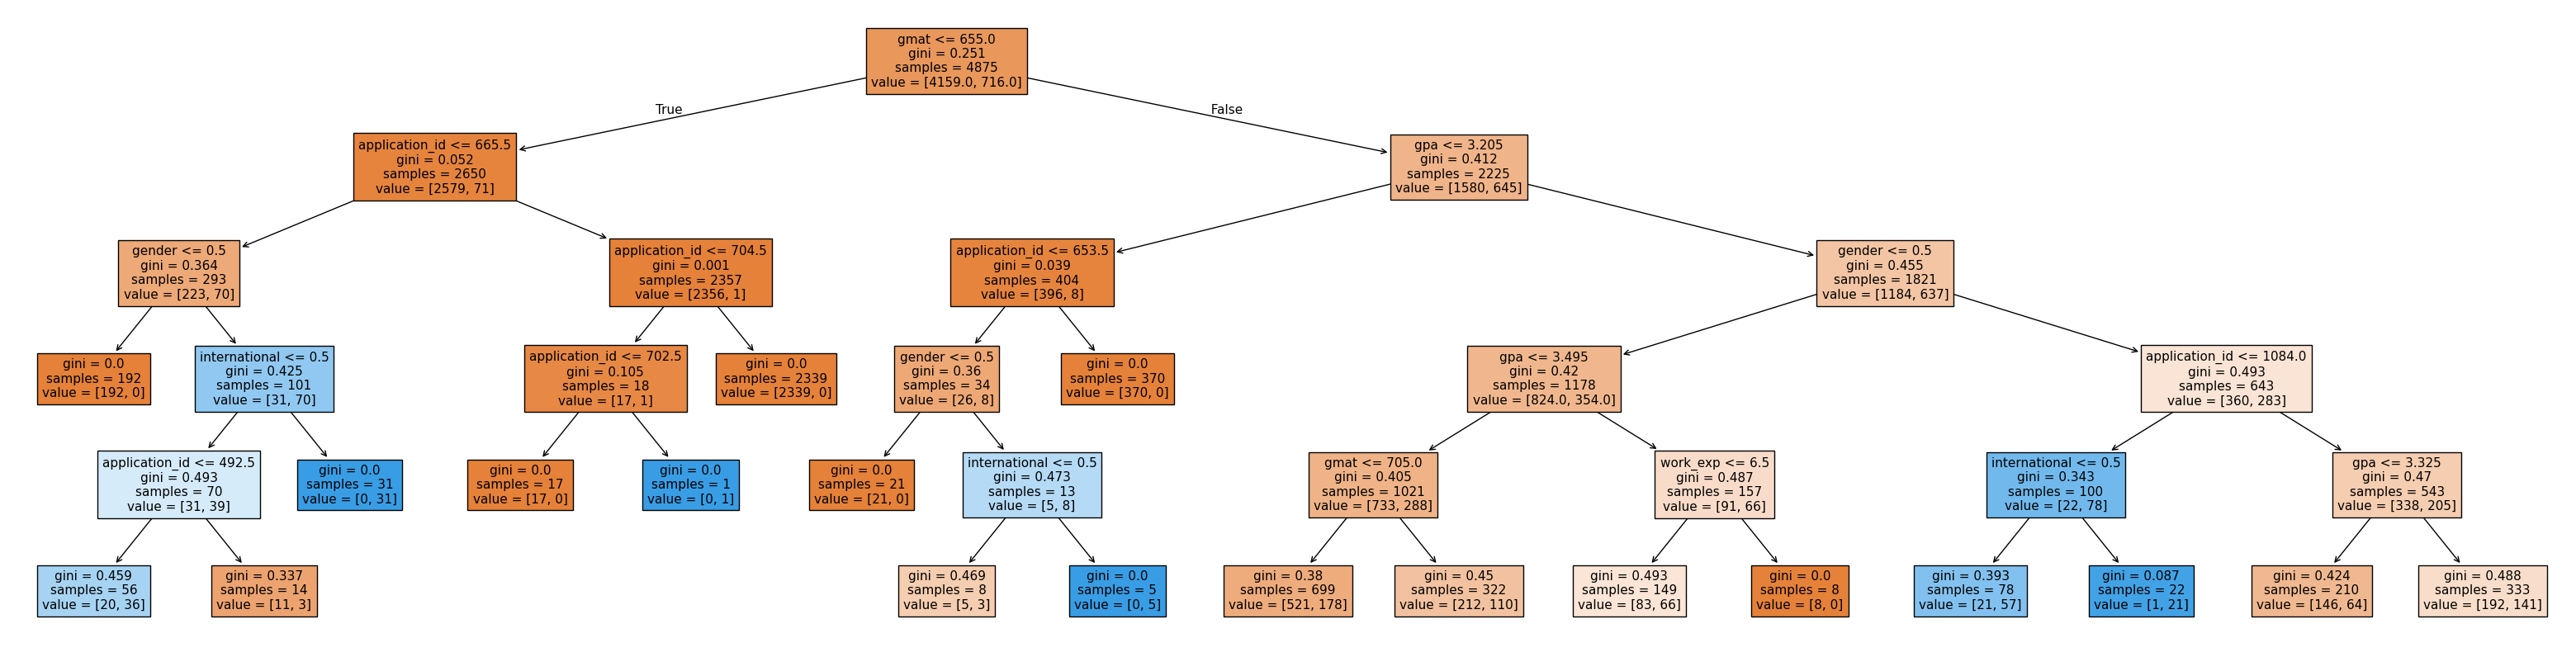

In [289]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(40,10))
plot_tree(clf, feature_names=(X.columns), filled=True)
plt.show()

## Étape 16 — Un arbre volontairement simple (max_depth=3)

On ré-entraîne un arbre limité à 3 niveaux : trop simple pour être performant, mais parfait pour ANALYSER — c'est lui qui servira pour l'importance des features (étapes suivantes).

In [290]:
tree = DecisionTreeClassifier(random_state=32,max_depth=3)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Rappel des 6 colonnes de X_train (l'ordre servira à lire le tableau d'importances).

In [291]:
X_train.columns

Index(['application_id', 'gender', 'international', 'gpa', 'gmat', 'work_exp'], dtype='str')

Construction du tableau feature ↔ importance.

In [292]:
importances = pd.DataFrame({'feature':X_train.columns,'importance':tree.feature_importances_})

## Étape 17 — L'importance des features, décodée

### 🧠 THÉORIE — D'où viennent ces chiffres ?
L'**importance** d'une feature = sa contribution totale à la réduction du Gini, sommée sur tous les nœuds où elle pose la question, normalisée pour que le total = 1. (Une feature jamais utilisée par l'arbre → importance = 0.)

**🔍 Lecture du résultat, ligne par ligne :**
| Feature | Importance | Interprétation |
|---|---|---|
| `gmat` | **0.475** | LA variable reine — près de la moitié du pouvoir discriminant (cohérent : c'est le critère académique n°1 des MBA) |
| `gender` | 0.226 | 2e — le genre pèse dans ces données (question d'équité à creuser dans la vraie vie !) |
| `gpa` | 0.204 | 3e — l'autre critère académique |
| `application_id` | **0.094** | 🚨 ANOMALIE ! Un numéro de dossier ne devrait RIEN prédire. L'arbre a trouvé un motif accidentel (peut-être les dossiers sont-ils numérotés dans un ordre corrélé aux décisions ?). C'est la conséquence directe d'avoir laissé cette colonne dans X (cf. étape features) — un « data leakage » discret ! |
| `international`, `work_exp` | 0.000 | Jamais utilisées par cet arbre à 3 niveaux — pas forcément inutiles dans l'absolu, mais dominées par gmat/gpa/gender à cette profondeur |

In [293]:
importances

,feature,importance
0,application_id,0.094201
1,gender,0.226407
2,international,0.000000
3,gpa,0.204329
4,gmat,0.475064
5,work_exp,0.000000


## Étape 18 — Préparer la VISUALISATION de la décision : passer en 2D

On garde les 2 features académiques les plus importantes (`gmat`, `gpa`). **Pourquoi 2 ?** Parce qu'un graphique a 2 axes ! Avec 6 features, la « frontière de décision » vit en 6 dimensions — invisualisable. En 2D, on va pouvoir DESSINER ce que le modèle décide en chaque point du plan.

In [294]:
feature_1 = "gmat"
feature_2 = "gpa"


`X_train_2d` : le train réduit aux colonnes gmat/gpa.

In [295]:
X_train_2d = X_train[[feature_1,feature_2]]

`X_test_2d` : idem pour le test.

In [296]:
X_test_2d = X_test[[feature_1,feature_2]]

## ⭐ Étape 19 — L'arme anti-déséquilibre : `class_weight="balanced"`

**Ce que fait ce paramètre :** pendant l'apprentissage, chaque candidat « Admit » (classe rare) compte **~5.8 fois plus lourd** qu'un « Deny » (poids = inversement proportionnels aux fréquences : 85/15). Rater un admis coûte cher → l'arbre est FORCÉ de s'intéresser à la classe minoritaire.

**C'est LA réponse structurelle au problème traîné depuis S3_P1 !** (Disponible aussi sur `LogisticRegression` et d'autres modèles.) On combine ici : profondeur 5 + poids équilibrés + 2 features → un modèle simple, visualisable et équitable entre classes.

In [297]:
tree_2d = DecisionTreeClassifier(random_state=32,max_depth=5,class_weight="balanced")
tree_2d.fit(X_train_2d,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",32
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

**Préparer le cadre du graphique :** on calcule les bornes min/max de gmat et gpa (± 0.5 de marge) — le rectangle du plan qu'on va cartographier.

In [298]:
x_min = X_train_2d[feature_1].min() - 0.5
x_max = X_train_2d[feature_1].max() + 0.5
y_min = X_train_2d[feature_2].min() - 0.5
y_max = X_train_2d[feature_2].max() + 0.5

x_min ≈ 569.5 (gmat minimum − 0.5).

In [299]:
x_min

np.float64(569.5)

x_max ≈ 780.5.

In [300]:
x_max

np.float64(780.5)

## Étape 20 — `np.meshgrid` : quadriller le plan

**Ce que fait le code :** `np.linspace(x_min, x_max, 300)` crée 300 valeurs régulièrement espacées de gmat ; idem pour gpa. `np.meshgrid` les croise → **une grille de 300×300 = 90 000 points** couvrant tout le rectangle.

**Le plan (génial) :** on va demander au modèle sa prédiction pour CHACUN de ces 90 000 points fictifs → on saura ce que l'arbre déciderait pour N'IMPORTE QUEL couple (gmat, gpa) → on pourra COLORIER les zones de décision.

In [301]:
import numpy as np
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300), 
    np.linspace(y_min, y_max, 300))

`ravel()` aplatit les grilles 2D en longues listes 1D, et on construit un DataFrame `grid` de 90 000 lignes avec les MÊMES noms de colonnes que X_train_2d (obligatoire pour que `predict` accepte).

In [302]:
grid = pd.DataFrame({feature_1: xx.ravel(), feature_2: yy.ravel()})

Aperçu de la grille : 90 000 combinaisons (gmat, gpa) — de (569.5, 2.15) à (780.5, 4.26).

In [303]:
grid

,gmat,gpa
0,569.500000,2.15
1,570.205686,2.15
2,570.911371,2.15
3,571.617057,2.15
4,572.322742,2.15
...,...,...
89995,777.677258,4.26
89996,778.382943,4.26
89997,779.088629,4.26
89998,779.794314,4.26


`Z = tree_2d.predict(grid)` → 90 000 prédictions (0 ou 1), puis `reshape(xx.shape)` les réorganise en grille 300×300 alignée avec le plan.

In [304]:
Z = tree_2d.predict(grid)
Z = Z.reshape(xx.shape)

Aperçu de Z : une matrice de 0 et de 1 — la « carte des décisions » brute (les zones de 1 sont minoritaires, on les verra mieux en couleur).

In [305]:
Z

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 300))

Création de la figure (8×6 pouces) pour le graphique final.

In [306]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

## ⭐ Étape 21 — LE graphique : la frontière de décision

**Ce que fait le code, couche par couche :**
- `plt.contourf(xx, yy, Z, alpha=0.3)` → **colorie le fond** : chaque zone du plan prend la couleur de la classe que le modèle y prédit (transparence 30 % pour voir à travers).
- `plt.scatter(..., c=y_train, edgecolor="k")` → superpose les **vrais candidats du train**, colorés par leur VRAIE classe (contour noir pour la lisibilité).

**🔍 Comment lire ce graphique, étape par étape :**
1. **Le fond coloré** = ce que le modèle PENSE : « toute candidature qui tombe ici sera prédite Admit/Deny ».
2. **Les frontières sont RECTANGULAIRES** (marches d'escalier) — signature des arbres ! Chaque question (« gmat ≤ 645 ? ») coupe le plan par une droite verticale ou horizontale, jamais oblique. (Une LR aurait tracé UNE droite oblique unique.)
3. **Points vs fond** : un point « Admit » sur fond « Admit » = bien classé ✅ ; sur fond « Deny » = raté ❌. Cherche les zones où les erreurs se concentrent (souvent : gmat élevé mais gpa moyen — la zone grise du recrutement !).
4. **Effet du `class_weight="balanced"`** : la zone « Admit » est plus étendue qu'elle ne le serait sans les poids — le modèle ose prédire la classe rare.

Text(0.5, 1.0, 'Decision surface using the most important features')

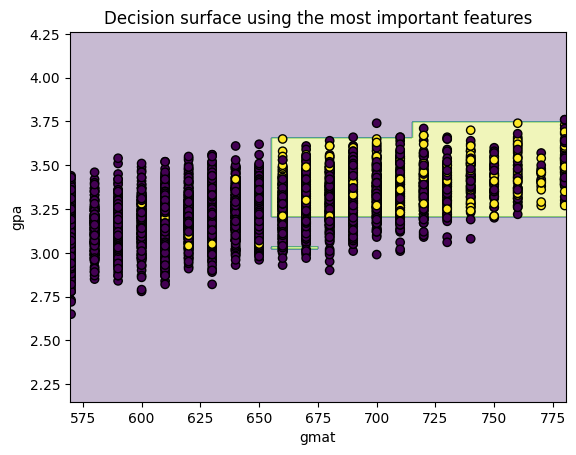

In [307]:
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_2d[feature_1], X_train_2d[feature_2], c=y_train, edgecolor="k")
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Decision surface using the most important features")

Prédiction du modèle 2D sur le test (X_test_2d).

In [308]:
y_pred_2d = tree_2d.predict(X_test_2d)

## Étape 22 — La matrice brute : l'effet `class_weight` chiffré

```
[[748, 287],    ← vrais Deny : 748 ✅, 287 pris pour Admit ❌
 [ 19, 165]]    ← vrais Admit : 19 ratés ❌, 165 détectés ✅ !
```

**🔍 Le calcul qui change tout :** rappel Admit = 165/(165+19) = **90 %** !! (contre 3 % pour la LR de l'étape 6 !). Le prix payé : 287 faux « Admit » (précision = 165/452 ≈ 37 %).

**La leçon :** `class_weight="balanced"` a déplacé le curseur prudence→audace. Selon l'usage métier (présélection large ? décision finale ?), ce compromis est excellent ou inacceptable — à TOI (ou au client) de choisir le curseur, pas à l'algorithme.

In [309]:
confusion_matrix(y_test,y_pred_2d)

array([[748, 287],
       [ 19, 165]])

Installation du package `supertree` (visualisation interactive d'arbres). Le `%pip install` dans une cellule installe directement depuis le notebook.

In [312]:
%pip install superTree

Note: you may need to restart the kernel to use updated packages.


Création de l'objet SuperTree : on lui passe le modèle, les données train, les noms de colonnes, et les noms de classes lisibles (`["Deny","Admit"]`).

In [316]:
from supertree import SuperTree

super_tree = SuperTree(tree_2d, X_train_2d.values, y_train.values, list(X_train_2d.columns.values), ["Deny", "Admit"])

## Étape 23 — SuperTree : l'arbre interactif

`show_tree()` affiche le même contenu que `plot_tree` (questions, gini, samples, value) mais en **widget interactif** : zoom, plier/déplier les branches, survol pour les détails. Idéal pour EXPLORER un arbre profond ; `plot_tree` reste mieux pour un rapport figé (image exportable).

## 📝 Résumé du notebook (les 5 idées à retenir)
1. **`balanced_accuracy`** (moyenne des rappels ; 0.5 = hasard) : le détecteur de mensonge des datasets déséquilibrés — LR 0.508, KNN 0.510, arbre 0.674.
2. **L'arbre de décision** : questions binaires qui minimisent le Gini ; interprétable ; surapprend sans max_depth.
3. **max_depth=5 : accuracy ↑ mais balanced accuracy ↓** — précision et rappel sont un curseur, pas une échelle unique.
4. **Importance des features** : gmat roi (0.475)… et `application_id` à 0.09 = signal d'alarme (colonne à retirer !).
5. **`class_weight="balanced"`** : rappel Admit de 3 % → 90 % (au prix de la précision). La frontière de décision rectangulaire rend tout ça VISIBLE.

In [318]:
super_tree.show_tree()